# 1. 모델 불러오기

In [1]:
import torch

print(torch.__version__)

2.10.0+cu126


In [1]:
from ultralytics import YOLO

from lib.utils.path import model_path

model = YOLO(model_path('yolo26n-seg.pt'))

# 2. 예측하기

In [6]:
import matplotlib.pyplot as plt

from lib.utils.path import data_path

preds = model.predict(
    source=data_path() / 'images' / 'bus.jpg', save=True, project='output'
)

# plt.imshow(preds)
# plt.show()


image 1/1 c:\Workspaces\model_lab\data\images\bus.jpg: 640x480 4 persons, 1 bus, 84.6ms
Speed: 4.4ms preprocess, 84.6ms inference, 22.6ms postprocess per image at shape (1, 3, 640, 480)
Results saved to C:\Workspaces\model_lab\runs\segment\output\predict4


In [7]:
print(type(preds))
print(len(preds))

<class 'list'>
1


In [8]:
pred = preds[0]
pred

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair

In [9]:
print(len(pred.masks.data))

5


In [ ]:
print(pred.masks.data[0].shape)
pred.masks.data[0]

tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]], device='cuda:0', dtype=torch.uint8)

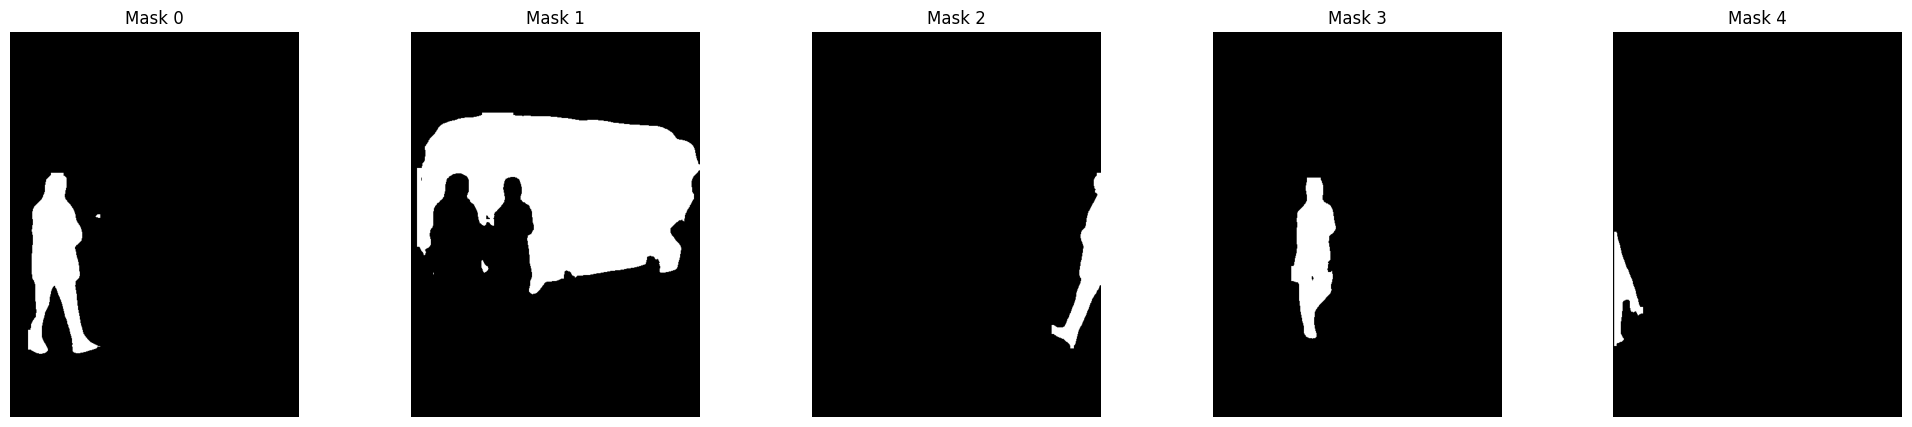

In [ ]:
import matplotlib.pyplot as plt  # noqa: F811

masks = pred.masks.data
n = len(masks)

fig, axes = plt.subplots(1, n, figsize=(n * 5, 5))

# 객체가 하나뿐일 때를 대비해 axes를 리스트로 처리
if n == 1:
    axes = [axes]

for i, data in enumerate(masks):
    axes[i].imshow(data.cpu(), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'Mask {i}')

plt.show()

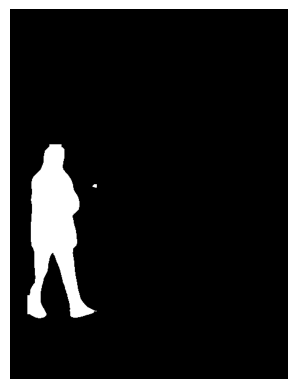

In [17]:
import matplotlib.pyplot as plt

idx = 0

plt.imshow(pred.masks.data[idx].cpu(), cmap='gray')
plt.axis('off')
plt.show()

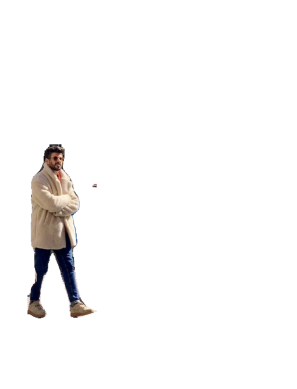

In [ ]:
import numpy as np
from PIL import Image

index = 0

orig = Image.fromarray(pred.orig_img[:, :, ::-1])

masks = pred.masks
mask = masks.data[index].cpu().numpy()
mask_resized = Image.fromarray((mask * 255).astype(np.uint8)).resize(
    (orig.width, orig.height), Image.NEAREST
)

orig_rgba = orig.convert('RGBA')
orig_array = np.array(orig_rgba)
orig_array[:, :, 3] = np.array(mask_resized)
masked_img = Image.fromarray(orig_array)

plt.imshow(masked_img)
plt.axis('off')
plt.show()

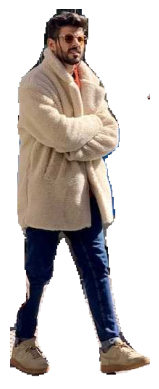

In [19]:
import numpy as np
from PIL import Image

index = 0

orig = Image.fromarray(pred.orig_img[:, :, ::-1])

masks = pred.masks
mask = masks.data[index].cpu().numpy()
mask_resized = Image.fromarray((mask * 255).astype(np.uint8)).resize(
    (orig.width, orig.height), Image.NEAREST
)

orig_rgba = orig.convert('RGBA')
orig_array = np.array(orig_rgba)
orig_array[:, :, 3] = np.array(mask_resized)
masked_img = Image.fromarray(orig_array)

x1, y1, x2, y2 = pred.boxes.xyxy[index].int().tolist()
crop_img = masked_img.crop((x1, y1, x2, y2))

plt.imshow(crop_img)
plt.axis('off')
plt.show()

In [ ]:
pred.boxes.cls  # 에측값

tensor([0., 5., 0., 0., 0.], device='cuda:0')

In [22]:
names = pred.names
print(names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [26]:
pred_idx_list = pred.boxes.cls

for i in pred_idx_list:
    print(i)
    print(i.cpu())
    print(int(i.cpu()))
    print(names[int(i.cpu())])
    print('=' * 100)

tensor(0., device='cuda:0')
tensor(0.)
0
person
tensor(5., device='cuda:0')
tensor(5.)
5
bus
tensor(0., device='cuda:0')
tensor(0.)
0
person
tensor(0., device='cuda:0')
tensor(0.)
0
person
tensor(0., device='cuda:0')
tensor(0.)
0
person
